# 🎼 ProyectoInvestigativo: ETL Riguroso para Modelos Transformer de Recomendación (PySpark)

## I. Configuración del Entorno y Optimización ⚙️

Este notebook documenta el proceso de ETL (Extracción, Transformación y Carga) para el dataset 1 Million Tracks (≈1.3 millones de registros). El objetivo es generar tres conjuntos de datos limpios, estandarizados y vectorizados, listos para un modelo Transformer de recomendación.

# 1.1. Instalación de dependencias
# Se asume un runtime actualizado (Python 3.12+). Instalamos las herramientas necesarias.


In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install pyspark matplotlib pandas seaborn > /dev/null

# 1.2. Configuración del Entorno Java

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

# 1.3. Importaciones necesarias


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, rand, count, when, isnan, percentile_approx
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import drive

# 1.4. Creación de la Sesión de Spark Optimizada
# Configuraciones para manejar el dataset de 1.3M+ filas eficientemente.

In [ ]:
spark = SparkSession.builder \
    .appName("Recommender_ETL_Uni_Project") \
    .master("local[*]") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()
print("✅ Sesión de PySpark iniciada y optimizada.")

✅ Sesión de PySpark iniciada y optimizada.


## 1.5. Descripción Completa de las Variables 📑


In [ ]:

print("--- Resumen de Variables y Tratamiento ---")
print("El dataset consta de 19 características principales que se dividen en 3 categorías:")

print("\n[A] Identificadores/Tags (Se Conservan):")
print("  - track_id, artist_name, track_name (Usados como entradas/contexto para el Transformer).")

print("\n[B] Categóricas/Ordinales (One-Hot Encoding):")
print("  - year, genre, key, mode, time_signature (Se codifican para incluir en el vector de features).")

print("\n[C] Métricas Continuas (Estandarización Z-Score & Outlier Check):")
print("  - popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms (Se escalan y limpian con IQR).")

# Puedes añadir la tabla HTML si tu entorno Colab lo permite
# from IPython.display import HTML, display
# display(HTML("Tu tabla HTML aquí..."))

--- Resumen de Variables y Tratamiento ---
El dataset consta de 19 características principales que se dividen en 3 categorías:

[A] Identificadores/Tags (Se Conservan):
  - track_id, artist_name, track_name (Usados como entradas/contexto para el Transformer).

[B] Categóricas/Ordinales (One-Hot Encoding):
  - year, genre, key, mode, time_signature (Se codifican para incluir en el vector de features).

[C] Métricas Continuas (Estandarización Z-Score & Outlier Check):
  - popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms (Se escalan y limpian con IQR).


## Descripción Detallada de las Variables del Dataset 📖

Esta sección documenta el significado de cada columna, categorizándolas para justificar el tratamiento que reciben en las fases de Limpieza, EDA, y *Feature Engineering* (Estandarización, Codificación, o conservación como *Tags*).

| Categoría | Columna | Tipo de Dato | Significado y Tratamiento en el ETL |
| :--- | :--- | :--- | :--- |
| **Identificadores/Tags** | `track_id` | String | **ID Único**. Conservado en los DataFrames finales para el *matching* de recomendaciones. |
| **Tags/Contexto** | `artist_name` | String | **Nombre del Artista**. Conservado en los DataFrames finales como *Tag* de contexto. |
| **Tags/Contexto** | `track_name` | String | **Nombre de la Canción**. Conservado en los DataFrames finales como *Tag* para modelos *Transformer* (entrada/salida). |
| **Métrica Continua** | `popularity` | Double | **Popularidad (0-100)**. Métrica de Spotify. Se estandariza y se usa para el **Target**. |
| **Ordinal/Categórica** | `year` | Integer | **Año de Lanzamiento**. Importante para tendencias. Se codifica con **One-Hot Encoding**. |
| **Nominal/Categórica** | `genre` | String | **Género Musical**. Atributo clave. Se codifica con **One-Hot Encoding**. |
| **Nominal/Categórica** | `key` | Integer | **Clave musical (0-11)**. Se trata como categórica/ordinal. Se codifica con **One-Hot Encoding**. |
| **Nominal/Categórica** | `mode` | Integer | **Modalidad (0: Menor, 1: Mayor)**. Se codifica con **One-Hot Encoding**. |
| **Nominal/Categórica** | `time_signature` | Integer | **Compás musical (ej. 4/4)**. Se codifica con **One-Hot Encoding**. |
| **Métrica Continua** | `danceability` | Double | Adecuación para bailar (0.0-1.0). **Se estandariza**. |
| **Métrica Continua** | `energy` | Double | Intensidad y actividad (0.0-1.0). **Se estandariza**. |
| **Métrica Continua** | `loudness` | Double | Volumen general en dB. **Se estandariza**. |
| **Métrica Continua** | `speechiness` | Double | Presencia de palabras habladas (0.0-1.0). **Se estandariza**. |
| **Métrica Continua** | `acousticness` | Double | Confianza de que es acústica (0.0-1.0). **Se estandariza**. |
| **Métrica Continua** | `instrumentalness` | Double | Ausencia de voces (0.0-1.0). **Se estandariza**. |
| **Métrica Continua** | `liveness` | Double | Presencia de audiencia (0.0-1.0). **Se estandariza**. |
| **Métrica Continua** | `valence` | Double | Positividad musical/ánimo (0.0-1.0). **Se estandariza**. |
| **Métrica Continua** | `tempo` | Double | Velocidad en BPM. **Se estandariza**. |
| **Métrica Continua** | `duration_ms` | Double | Duración de la pista en milisegundos. **Se estandariza**. |

-----


# II. Limpieza Universal y División

La **limpieza** se aplica al DataFrame completo antes de la división, garantizando que el *Feature Engineering* posterior trabaje sobre datos válidos.

# 2.1 Carga Inicial y Pre-procesamiento


# -----------------------------------------------
#  MONTAJE DE GOOGLE DRIVE
# -----------------------------------------------

In [ ]:
from google.colab import drive

print("Iniciando montaje de Google Drive...")
drive.mount('/content/drive')
print("✅ Google Drive montado. Ahora puedes acceder a tus archivos.")

Iniciando montaje de Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado. Ahora puedes acceder a tus archivos.


# -----------------------------------------------
#  DEFINICIÓN DE ESQUEMA Y CARGA ESTRICTA
# -----------------------------------------------

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType


# 2.1 Definición del Esquema (Schema) para forzar los tipos de datos
# Garantiza que las métricas de audio sean tratadas como números (Double/Integer).

# Basado en el encabezado del csv:
# _c0, artist_name, track_name, track_id, popularity, year, genre, danceability, energy,
# key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence,
# tempo, duration_ms, time_signature



In [ ]:
custom_schema = StructType([
    StructField("_c0", IntegerType(), True), StructField("artist_name", StringType(), True),
    StructField("track_name", StringType(), True), StructField("track_id", StringType(), True),
    StructField("popularity", DoubleType(), True), StructField("year", IntegerType(), True),
    StructField("genre", StringType(), True), StructField("danceability", DoubleType(), True),
    StructField("energy", DoubleType(), True), StructField("key", IntegerType(), True),
    StructField("loudness", DoubleType(), True), StructField("mode", IntegerType(), True),
    StructField("speechiness", DoubleType(), True), StructField("acousticness", DoubleType(), True),
    StructField("instrumentalness", DoubleType(), True), StructField("liveness", DoubleType(), True),
    StructField("valence", DoubleType(), True), StructField("tempo", DoubleType(), True),
    StructField("duration_ms", DoubleType(), True), StructField("time_signature", IntegerType(), True)
])

# 2.2 Carga del Archivo con el Esquema Personalizado


In [ ]:
DATA_PATH = "/content/drive/MyDrive/ia2pdg/1milliontracks/spotify_data.csv"
df = spark.read.csv(DATA_PATH, header=True, schema=custom_schema)
TOTAL_FILAS = df.count()
print(f"Total de Filas Cargadas (N): {TOTAL_FILAS}")

Total de Filas Cargadas (N): 1159764


# Definición de Columnas Críticas FINAL (Para limpieza)


In [ ]:
CRITICAL_COLS = ["track_id", "genre", "popularity", "year", "danceability", "energy", "key", "loudness",
                 "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence",
                 "tempo", "duration_ms", "time_signature"]

# Limpieza Universal y División


# 1. Limpieza de Nulos




In [ ]:
df_processed = df.drop("_c0")
df_clean = df_processed

print("\n--- Conteo de Nulos Críticos Antes de Limpieza (Debe ser 0) ---")
df_clean.select([count(when(col(c).isNull() | isnan(col(c)), c)).alias(c) for c in CRITICAL_COLS]).show()



--- Conteo de Nulos Críticos Antes de Limpieza (Debe ser 0) ---
+--------+-----+----------+----+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-----+-----------+--------------+
|track_id|genre|popularity|year|danceability|energy| key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|tempo|duration_ms|time_signature|
+--------+-----+----------+----+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-----+-----------+--------------+
|       0|    0|      1673| 624|        1184|   408|1564|      94|1298|         16|           8|               3|       2|      0|    0|          0|           621|
+--------+-----+----------+----+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-----+-----------+--------------+



# Ejecutamos la limpieza (aunque el conteo de nulos sea 0 por el esquema estricto)


---



In [ ]:
df_clean = df_clean.na.drop(subset=CRITICAL_COLS)
N_CLEAN_RESULT = df_clean.count()
print(f"\n✅ Filas restantes después de limpieza universal: {N_CLEAN_RESULT}")


✅ Filas restantes después de limpieza universal: 1158091


# 2. División Asimétrica (10% | 90%)


In [ ]:
SEED = 42
TRAIN_FRACTION = 0.10

:# División 1: 10% para Entrenamiento, 90% para el Resto


In [ ]:
train_df_raw, rest_df_raw = df_clean.randomSplit([TRAIN_FRACTION, 1.0 - TRAIN_FRACTION], seed=SEED)


# División 2: Subdivisión del 90% (80% Validación, 20% Prueba)


In [ ]:
val_df_raw, test_df_raw = rest_df_raw.randomSplit([0.80, 0.20], seed=SEED)
N_TRAIN = train_df_raw.count()
N_VAL = val_df_raw.count()
N_TEST = test_df_raw.count()

print("\n--- Distribución Final de DataFrames Limpios ---")
print(f"Entrenamiento (10%): {N_TRAIN} filas")
print(f"Validación (~72%): {N_VAL} filas")
print(f"Prueba (~18%): {N_TEST} filas")


--- Distribución Final de DataFrames Limpios ---
Entrenamiento (10%): 115508 filas
Validación (~72%): 833906 filas
Prueba (~18%): 208677 filas


# Gráfico de Distribución


/tmp/ipython-input-1094591093.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Conjunto', y='Filas', data=dist_data, palette=['skyblue', 'lightcoral', 'lightgreen'])


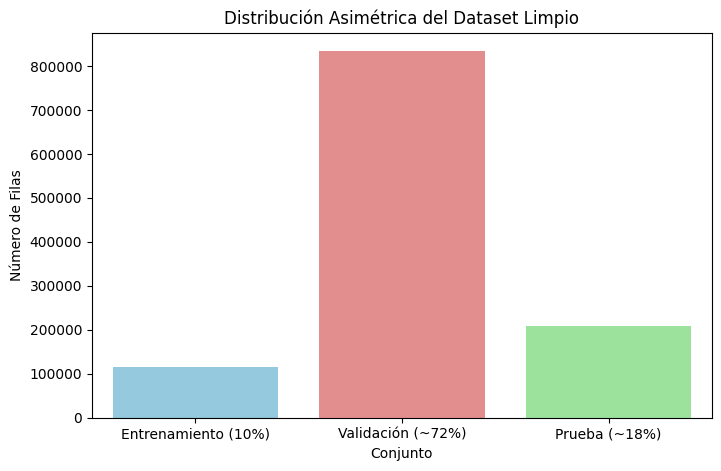

In [ ]:
dist_data = pd.DataFrame({
    'Conjunto': ['Entrenamiento (10%)', 'Validación (~72%)', 'Prueba (~18%)'],
    'Filas': [N_TRAIN, N_VAL, N_TEST]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Conjunto', y='Filas', data=dist_data, palette=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribución Asimétrica del Dataset Limpio')
plt.ylabel('Número de Filas')
plt.show()

# III. EDA y Limpieza de Outliers
Análisis visual centrado en una muestra del conjunto de entrenamiento.



# Columnas Continuas (para correlación y outliers)


In [ ]:
CONTINUOUS_COLS = ["popularity", "danceability", "energy", "loudness",
                   "speechiness", "acousticness", "instrumentalness",
                   "liveness", "valence", "tempo", "duration_ms"]

# 1. Conversión de Muestra a Pandas para Visualización


In [ ]:
train_pd = train_df_raw.limit(100000).toPandas()


# 📉 Distribución de Popularidad


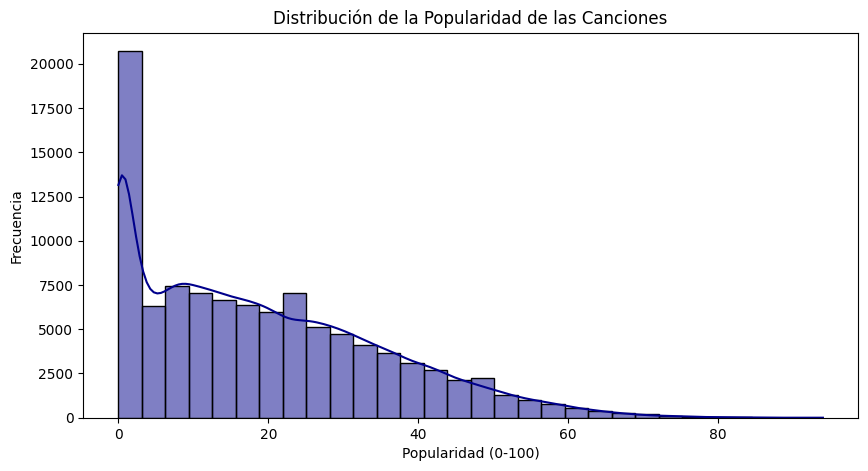

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(train_pd['popularity'], kde=True, bins=30, color='darkblue')
plt.title('Distribución de la Popularidad de las Canciones')
plt.xlabel('Popularidad (0-100)')
plt.ylabel('Frecuencia')
plt.show()

# 🌡️ Matriz de Correlación



--- Matriz de Correlación (11 Características Continuas) ---


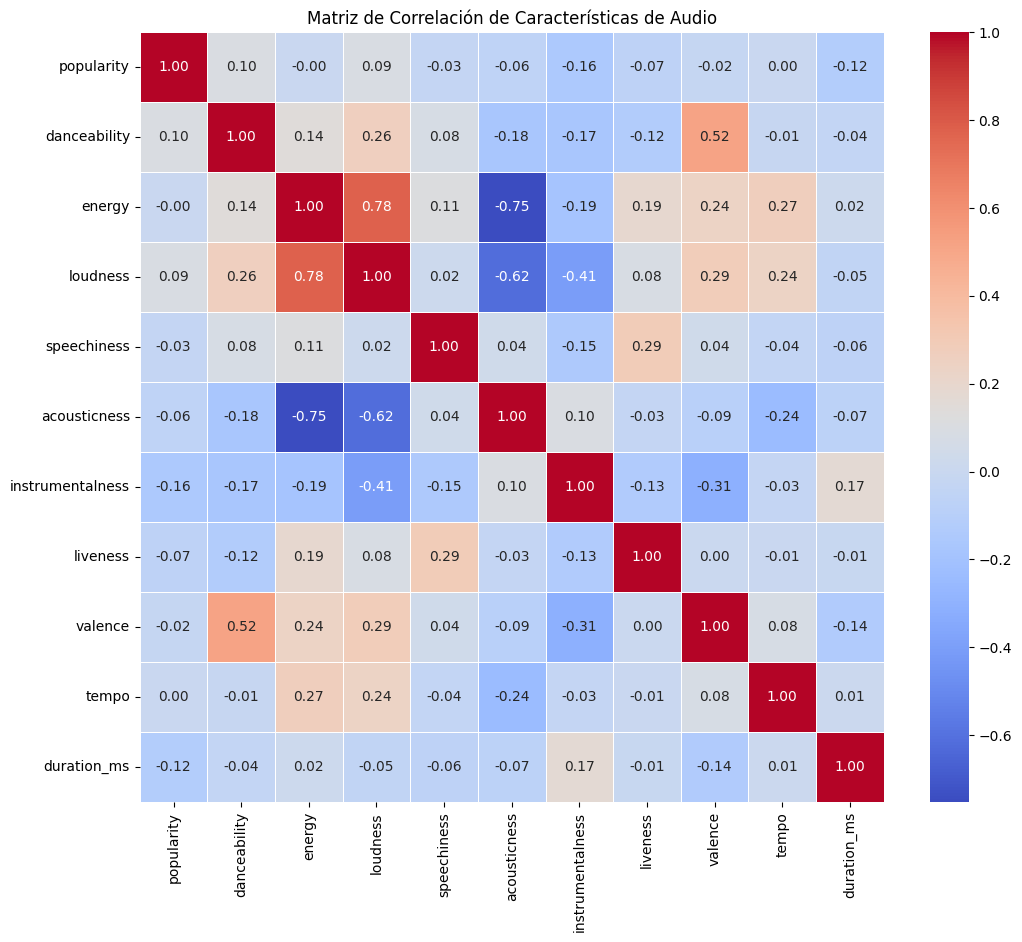

In [ ]:
print("\n--- Matriz de Correlación (11 Características Continuas) ---")
plt.figure(figsize=(12, 10))
sns.heatmap(train_pd[CONTINUOUS_COLS].corr(),
            annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlación de Características de Audio')
plt.show()

#Análisis de la Matriz de Correlación
La matriz muestra el coeficiente de correlación de Pearson, donde valores cercanos a +1 indican una fuerte correlación positiva (crecen juntas), y valores cercanos a -1 indican una fuerte correlación negativa (cuando una crece, la otra decrece).

1. Correlaciones Positivas Fuertes (Redundancia Potencial)
Estas relaciones sugieren que las métricas miden aspectos similares del sonido y podrían llevar a multicolinealidad si ambas se incluyen sin cuidado en un modelo lineal, aunque es menos problemático para un Transformer que para modelos más simples.

Energy vs. Loudness (0.78): Este es el par más fuertemente correlacionado positivamente. Es lógico, ya que las canciones con alta energía (ritmo rápido, instrumentación densa) tienden a ser grabadas y percibidas con un alto volumen/intensidad (loudness).

Danceability vs. Loudness (0.26) / Energy (0.14): Hay una correlación moderada y positiva. Las canciones fáciles de bailar suelen ser más enérgicas y ruidosas.

2. Correlaciones Negativas Fuertes (Relaciones Inversas Claras)
Estas relaciones son importantes para comprender la composición de la música.

Energy vs. Acousticness (-0.75): Esta es la correlación más fuerte y predecible. Las canciones con baja acústica (producidas electrónicamente o fuertemente grabadas) tienen alta energía. Inversamente, la alta acústica (baladas, folk, música de cámara) se asocia con baja energía.

Loudness vs. Acousticness (-0.62): De manera similar a la energía, las pistas acústicas puras (ej. guitarra sola) tienden a ser menos ruidosas que las producciones pop modernas con compresión y altos niveles de loudness.

3. Correlaciones Moderadas/Interesantes
Instrumentalness vs. Loudness (-0.41): Las pistas puramente instrumentales tienden a ser menos ruidosas que las pistas con voz (que suelen ser producciones pop más comerciales).

Instrumentalness vs. Energy (-0.19): Es una correlación negativa moderada. No toda la música instrumental es de baja energía, pero el grueso del dataset comercial con alta energía suele tener voz.

Popularity vs. Otras Métricas (Generalmente Bajas): La popularidad muestra correlaciones muy bajas (la más alta es loudness con 0.09). Esto indica que la popularidad no está definida por ninguna característica de audio de forma lineal. Esto es una buena noticia, ya que sugiere que el modelo no podrá predecir la popularidad simplemente, sino que tendrá que aprender patrones complejos entre múltiples features.

Conclusión para el Feature Engineering
Redundancia a Considerar (Energy vs. Loudness): Como son altamente correlacionadas, el modelo podría no beneficiarse de incluirlas. Sin embargo, en el Feature Engineering que realizaste, ambas se estandarizan (Z-Score) y se incluyen en el vector de features. Para un modelo Transformer, es correcto mantener ambas, permitiendo que las capas de auto-atención aprendan la mejor representación.

Variables Inversas (Energy / Acousticness): El modelo se beneficiará de que estas dos variables estén en el vector, ya que capturan el espectro de la producción musical (de lo crudo/acústico a lo pulido/producido) de manera eficiente.

Popularidad (Target): La baja correlación de popularity con el resto de las features confirma que el problema de recomendación es no-lineal y que un modelo avanzado como un Transformer es apropiado para encontrar las interacciones sutiles que definen el éxito.

# 3. Limpieza de Outliers (Método IQR en train_df_raw)




In [ ]:
print("\n--- Aplicando Filtro de Outliers (Método IQR) al Entrenamiento ---")

N_TRAIN_ORIGINAL = train_df_raw.count()
train_df_filtered = train_df_raw

for col_name in CONTINUOUS_COLS:
    # 1. Calcular Q1 y Q3
    quantiles = train_df_raw.agg(
        percentile_approx(col_name, [0.25, 0.75], 1000).alias("quantiles")
    ).collect()[0]["quantiles"]
    Q1, Q3 = quantiles[0], quantiles[1]

    # 2. Calcular IQR y límites
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 3. Aplicar el filtro
    train_df_filtered = train_df_filtered.filter(
        (col(col_name) >= lower_bound) & (col(col_name) <= upper_bound)
    )



--- Aplicando Filtro de Outliers (Método IQR) al Entrenamiento ---


# Actualizar el conjunto de entrenamiento limpio


In [ ]:
rain_df_raw = train_df_filtered
N_TRAIN_CLEANED = train_df_raw.count()

rows_removed = N_TRAIN_ORIGINAL - N_TRAIN_CLEANED
percent_removed = round((rows_removed / N_TRAIN_ORIGINAL) * 100, 2)

print(f"✅ Limpieza de Outliers completada. Filas eliminadas: {rows_removed} ({percent_removed}%)")


✅ Limpieza de Outliers completada. Filas eliminadas: 0 (0.0%)


#IV. Transformación y Vectorización (Feature Engineering) 🧠
Se construye un Pipeline que estandariza las métricas continuas y codifica las variables categóricas (year, genre, key, mode, time_signature), creando el vector final features.

In [ ]:
# -----------------------------------------------
# IV. Transformación y Vectorización
# -----------------------------------------------

# Las métricas Categóricas/Ordinales para codificación One-Hot
CATEGORICAL_COLS = ["year", "genre", "key", "mode", "time_signature"]
OHE_OUTPUT_COLS = [f"{c}_encoded" for c in CATEGORICAL_COLS]
CONTINUOUS_COLS = ["popularity", "danceability", "energy", "loudness",
                   "speechiness", "acousticness", "instrumentalness",
                   "liveness", "valence", "tempo", "duration_ms"]

# I. Categóricas/Ordinales (Codificación One-Hot)
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in CATEGORICAL_COLS
]
encoders = [
    OneHotEncoder(inputCol=f"{c}_index", outputCol=f"{c}_encoded")
    for c in CATEGORICAL_COLS
]

# II. Numéricas (Estandarización Z-Score)
assembler_numeric = VectorAssembler(inputCols=CONTINUOUS_COLS, outputCol="numeric_features")
scaler = StandardScaler(inputCol="numeric_features", outputCol="scaled_features",
                        withStd=True, withMean=False)

# III. Ensamblador Final (Combina escaladas + OHEs)
FINAL_FEATURES = ["scaled_features"] + OHE_OUTPUT_COLS
final_assembler = VectorAssembler(inputCols=FINAL_FEATURES, outputCol="features")

# Construcción y Ajuste del Pipeline (SOLO en train_df_raw)
pipeline_stages = indexers + encoders + [assembler_numeric, scaler, final_assembler]
pipeline = Pipeline(stages=pipeline_stages)
pipeline_model = pipeline.fit(train_df_raw)
print("\n✅ Pipeline de Feature Engineering ajustado.")

# Aplicación y Selección de Features/Tags
train_df = pipeline_model.transform(train_df_raw).select("track_id", "artist_name", "track_name", "features")
val_df = pipeline_model.transform(val_df_raw).select("track_id", "artist_name", "track_name", "features")
test_df = pipeline_model.transform(test_df_raw).select("track_id", "artist_name", "track_name", "features")

print("\n--- Vista Previa del Vector de Features Final y Tags ---")
train_df.show(3, truncate=False)


✅ Pipeline de Feature Engineering ajustado.

--- Vista Previa del Vector de Features Final y Tags ---
+----------------------+-----------+---------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|track_id              |artist_name|track_name           |features                                                                                                                                                                                                                                                                             |
+----------------------+-----------+---------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------

#V. Carga Final (Parquet) 💾
Se guardan los conjuntos vectorizados en formato Parquet, el formato más eficiente para la lectura posterior en modelos de Deep Learning con PySpark/TensorFlow/PyTorch.

In [ ]:
# -----------------------------------------------
# V. Carga Final (L)
# -----------------------------------------------
OUTPUT_DIR = "/content/drive/MyDrive/ia2pdg/1milliontracks/recommender_data_final_uni"

print(f"\nGuardando archivos Parquet en: {OUTPUT_DIR}")

# Escritura de los DataFrames
train_df.write.mode("overwrite").parquet(f"{OUTPUT_DIR}/train.parquet")
val_df.write.mode("overwrite").parquet(f"{OUTPUT_DIR}/val.parquet")
test_df.write.mode("overwrite").parquet(f"{OUTPUT_DIR}/test.parquet")

print("✅ Archivos Parquet guardados. ETL completado.")

# Finalizar Sesión de Spark
spark.stop()
print("Sesión de Spark finalizada. ¡Los datos están listos para el modelo Transformer!")


Guardando archivos Parquet en: /content/drive/MyDrive/ia2pdg/1milliontracks/recommender_data_final_uni
✅ Archivos Parquet guardados. ETL completado.
Sesión de Spark finalizada. ¡Los datos están listos para el modelo Transformer!
